In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
card_dataset = pd.read_csv('/content/creditcard.csv')

In [4]:
card_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
card_dataset.shape

(284807, 31)

In [6]:
card_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
card_dataset.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


- 0 = Legit
- 1 = Fraud

In [8]:
card_dataset['Class'].value_counts()


,count
Class,
0,284315
1,492


In [9]:
legit = card_dataset[card_dataset.Class == 0]
fraud = card_dataset[card_dataset.Class == 1]

In [10]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [12]:
legit.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [13]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [14]:
card_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,0.009824,-0.006576,0.010832,0.000189,0.012064,0.000161,0.007164,0.011535,0.003887,-0.001178,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,3.800173,-6.259393,-0.109334,-6.971723,-0.092929,-4.139946,-6.665836,-2.246308,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Dataset is imbalance that's why I'm taking radom transactions from legit.

In [15]:
legit_sample = legit.sample(n=492)

In [16]:
credit_card_dataset = pd.concat([legit_sample, fraud], axis=0)

In [17]:
credit_card_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
137225,82072.0,-1.323993,0.077667,2.138717,0.557824,-1.177525,2.293411,-1.284247,0.893794,0.391962,1.002263,-1.237084,-0.597511,-1.863375,-0.839156,-1.479151,-2.212991,0.678308,2.065937,0.979184,-0.635876,-0.391767,-0.100232,-0.277473,-1.197478,-0.185131,-0.138440,-1.008423,-0.698875,29.05,0
123646,77009.0,-0.936453,1.006224,0.830815,0.235568,-0.052606,-0.978703,0.562573,0.185123,-0.577565,-0.671097,-0.809261,0.317866,0.223379,0.309904,-0.218354,-0.333563,0.132495,-0.435220,0.270991,-0.197035,0.066798,0.192586,-0.043934,0.440719,0.286504,0.403334,-0.221643,-0.043787,15.73,0
50322,44442.0,-1.756421,2.470268,-3.696764,1.797293,-0.658082,-1.942159,-0.483975,1.587363,-0.573887,-1.007692,1.945215,0.323555,-0.890192,-2.076015,0.406819,1.507308,3.335178,2.157604,-0.308353,-0.025424,-0.035765,-0.247373,0.237617,0.172421,-0.322337,-0.411305,0.145622,-0.199301,44.99,0
248436,153943.0,2.237654,-1.417598,-0.416335,-1.702766,-1.352776,-0.016486,-1.515428,0.088616,-1.304294,1.664780,0.881209,0.215216,0.848401,-0.493238,-0.594250,-0.111962,0.147933,0.207583,0.077639,-0.393234,-0.351582,-0.560205,0.503354,0.643314,-0.622968,-0.534296,0.036971,-0.038817,4.95,0
137825,82347.0,-1.151751,0.179532,1.793078,-0.411114,0.879027,-1.216259,0.944930,-0.223973,-0.782475,-0.384577,1.324589,0.219979,-0.873809,0.426353,-0.380138,0.226005,-0.737154,0.120329,-0.387761,0.178290,0.071513,-0.006887,-0.189469,0.536566,0.514611,0.225613,-0.241904,-0.170377,42.81,0


In [19]:
credit_card_dataset.shape

(984, 31)

In [20]:
credit_card_dataset['Class'].value_counts()

,count
Class,
0,492
1,492


In [21]:
credit_card_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,93269.634146,0.106363,-0.025773,-0.004939,-0.017009,0.040600,-0.029021,-0.020731,0.010082,0.020249,0.039897,-0.008740,0.002372,-0.039899,-0.006245,0.020286,-0.014190,0.030617,-0.020196,-0.046043,-0.013705,0.007087,-0.018977,-0.002378,-0.03726,0.004540,0.016506,0.015293,-0.001310,80.786463
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,3.800173,-6.259393,-0.109334,-6.971723,-0.092929,-4.139946,-6.665836,-2.246308,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.10513,0.041449,0.051648,0.170575,0.075667,122.211321


In [22]:
X = credit_card_dataset.drop(columns='Class', axis=1)
Y = credit_card_dataset['Class']

In [23]:
print(X)
print(Y)

            Time        V1        V2  ...       V27       V28  Amount
137225   82072.0 -1.323993  0.077667  ... -1.008423 -0.698875   29.05
123646   77009.0 -0.936453  1.006224  ... -0.221643 -0.043787   15.73
50322    44442.0 -1.756421  2.470268  ...  0.145622 -0.199301   44.99
248436  153943.0  2.237654 -1.417598  ...  0.036971 -0.038817    4.95
137825   82347.0 -1.151751  0.179532  ... -0.241904 -0.170377   42.81
...          ...       ...       ...  ...       ...       ...     ...
279863  169142.0 -1.927883  1.125653  ...  0.292680  0.147968  390.00
280143  169347.0  1.378559  1.289381  ...  0.389152  0.186637    0.76
280149  169351.0 -0.676143  1.126366  ...  0.385107  0.194361   77.89
281144  169966.0 -3.113832  0.585864  ...  0.884876 -0.253700  245.00
281674  170348.0  1.991976  0.158476  ...  0.002988 -0.015309   42.53

[984 rows x 30 columns]
137225    0
123646    0
50322     0
248436    0
137825    0
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Nam

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [31]:
print(X.shape, X_train.shape, X_test.shape)

(984, 30) (787, 30) (197, 30)


In [32]:
model = LogisticRegression()

In [33]:
model.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [34]:
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [35]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.9453621346886912


In [36]:
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [37]:
print('Accuracy score on Test Data : ', test_data_accuracy)

Accuracy score on Test Data :  0.9086294416243654


In [38]:
cm = confusion_matrix(Y_test, X_test_prediction)
print(cm)

[[94  5]
 [13 85]]


In [39]:
cp = classification_report(Y_test, X_test_prediction)
print(cp)

              precision    recall  f1-score   support

           0       0.88      0.95      0.91        99
           1       0.94      0.87      0.90        98

    accuracy                           0.91       197
   macro avg       0.91      0.91      0.91       197
weighted avg       0.91      0.91      0.91       197



/tmp/ipykernel_40905/1025704353.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


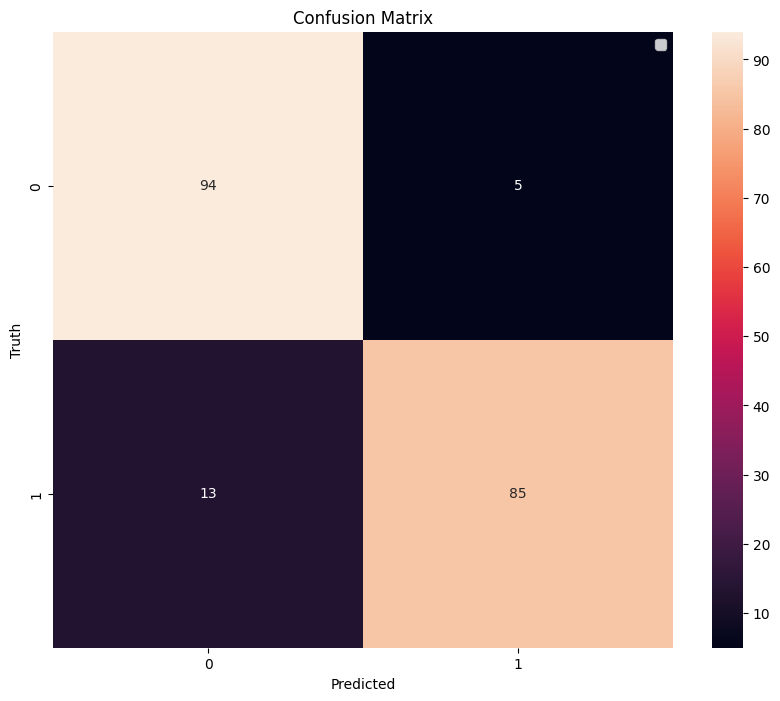

In [42]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.legend()
plt.show()